In [1]:
from google import genai
from google.genai import types
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import umap
from datasets import load_dataset

/Users/shreyanakum/Documents/knowledge-gaps/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
ds = load_dataset("qwedsacf/competition_math")
print(type(ds))

<class 'datasets.dataset_dict.DatasetDict'>


In [2]:
client = genai.Client()

In [4]:
ds.column_names

{'train': ['problem', 'level', 'type', 'solution']}

In [28]:
problems = ds['train'][:75]['problem']

texts = list(problems)

In [29]:
result = [
    np.array(e.values) for e in client.models.embed_content(
        model="gemini-embedding-001",
        contents=texts,
        config=types.EmbedContentConfig(task_type="CLUSTERING")).embeddings
]

embeddings_matrix = np.array(result)
similarity_matrix = cosine_similarity(embeddings_matrix)

for i, text1 in enumerate(texts):
    for j in range(i + 1, len(texts)):
        text2 = texts[j]
        similarity = similarity_matrix[i, j]
        print(f"Similarity between '{text1}' and '{text2}': {similarity:.4f}")

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=2, min_dist=0.1, init='random') # init='spectral' for larger
embeddings_2d = reducer.fit_transform(embeddings_matrix)

Similarity between 'Let \[f(x) = \left\{
\begin{array}{cl} ax+3, &\text{ if }x>2, \\
x-5 &\text{ if } -2 \le x \le 2, \\
2x-b &\text{ if } x <-2.
\end{array}
\right.\]Find $a+b$ if the piecewise function is continuous (which means that its graph can be drawn without lifting your pencil from the paper).' and 'A rectangular band formation is a formation with $m$ band members in each of $r$ rows, where $m$ and $r$ are integers. A particular band has less than 100 band members. The director arranges them in a rectangular formation and finds that he has two members left over. If he increases the number of members in each row by 1 and reduces the number of rows by 2, there are exactly enough places in the new formation for each band member. What is the largest number of members the band could have?': 0.7875
Similarity between 'Let \[f(x) = \left\{
\begin{array}{cl} ax+3, &\text{ if }x>2, \\
x-5 &\text{ if } -2 \le x \le 2, \\
2x-b &\text{ if } x <-2.
\end{array}
\right.\]Find $a+b$ if the pi

/Users/shreyanakum/Documents/knowledge-gaps/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### UMAP

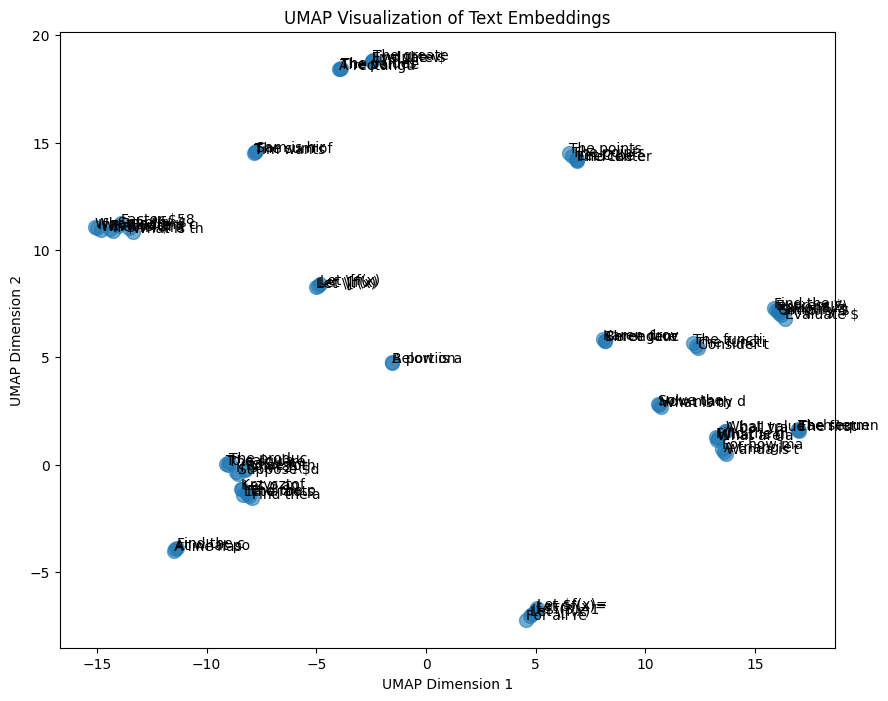

In [33]:
plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=100, alpha=0.6)

for i, txt in enumerate(texts):
    plt.annotate(txt[:10], (embeddings_2d[i, 0], embeddings_2d[i, 1]))

plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title('UMAP Visualization of Text Embeddings')
plt.savefig("./umap.png")

### PaCMAP